In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

#### **Modelo individual: fórmula de De Pril**

Cartera de 21 pólizas con montos de 2, 3, 4 y 5 y probabilidades de reclamación de 0.04, 0.05 y 0.06. Se calcula la distribución exacta de S con la fórmula de De Pril y el valor más pequeño de p tal que P(S > p) ≤ 0.05.

In [9]:
# Datos: filas = probabilidad de reclamación, columnas = monto
montos = np.array([2, 3, 4, 5])
q = np.array([0.04, 0.05, 0.06])
n_polizas = np.array([
    [1, 1, 2, 1],
    [0, 2, 3, 3],
    [1, 1, 2, 4]
])

# E[S] y Var(S)
E_S = np.sum(n_polizas * montos * q[:, None])
Var_S = np.sum(n_polizas * montos**2 * (q * (1 - q))[:, None])

print(f"E[S] = {E_S:.4f}")
print(f"Var(S) = {Var_S:.4f}")

E[S] = 4.3500
Var(S) = 17.5635


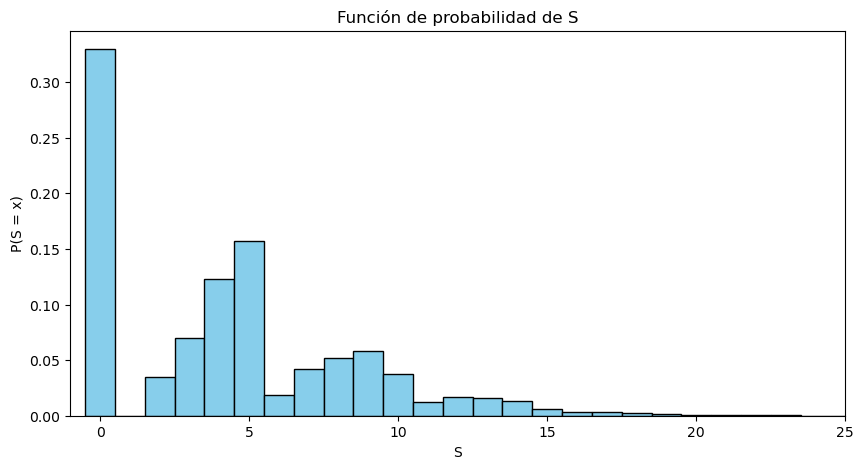

El valor más pequeño de p que satisface P(S > p) ≤ 0.05 es p = 12


In [10]:
# Método de De Pril
def h(i, k):
    if i not in montos:
        return 0.0
    j = np.where(montos == i)[0][0]
    return i * (-1)**(k - 1) * np.sum(n_polizas[:, j] * (q / (1 - q))**k)

max_S = int(np.sum(n_polizas * montos))
g = np.zeros(max_S + 1)
g[0] = np.prod((1 - q) ** n_polizas.sum(axis=1))

for x in range(1, max_S + 1):
    suma = 0.0
    for i in range(1, min(x, montos.max()) + 1):
        for k in range(1, x // i + 1):
            suma += g[x - i * k] * h(i, k)
    g[x] = suma / x

s_vals = np.arange(max_S + 1)

plt.figure(figsize=(10, 5))
plt.bar(s_vals, g, color='skyblue', edgecolor='black', width=1.0)
plt.title("Función de probabilidad de S")
plt.xlabel("S")
plt.ylabel("P(S = x)")
plt.xlim(-1, 25)
plt.grid(False)
plt.show()

# Valor más pequeño de p que satisface P(S > p) ≤ 0.05
cdf = np.cumsum(g)
p_corte = s_vals[np.argmax(1 - cdf <= 0.05)]
print(f"El valor más pequeño de p que satisface P(S > p) ≤ 0.05 es p = {p_corte}")

#### **Percentil 95 de S: simulación vs aproximaciones**

S es Poisson compuesta con λ = 50 y montos X ~ U(0, 10). Se busca p tal que P(S > p) = 0.05 por simulación (10,000 valores) y con las aproximaciones Normal, Gamma y Gamma trasladada.

In [ ]:
# Simulación
np.random.seed(42)
lam = 50
a = 10
n_sim = 10000

N = np.random.poisson(lam, size=n_sim)
S = np.array([np.sum(np.random.uniform(0, a, n)) for n in N])
p_sim = np.quantile(S, 0.95)

# Momentos de X ~ U(0, 10)
E_X = a / 2
E_X2 = a**2 / 3
E_X3 = a**3 / 4

# Momentos de S
mu_S = lam * E_X
Var_S = lam * E_X2
sigma_S = np.sqrt(Var_S)
alpha3 = lam * E_X3 / sigma_S**3

# Aproximación Normal
p_normal = norm.ppf(0.95, loc=mu_S, scale=sigma_S)

# Aproximación Gamma
p_gamma = gamma.ppf(0.95, a=mu_S**2 / Var_S, scale=Var_S / mu_S)

# Aproximación Gamma trasladada
k = mu_S - 2 * sigma_S / alpha3
p_gamma_tras = k + gamma.ppf(0.95, a=4 / alpha3**2, scale=sigma_S * alpha3 / 2)

print("Percentil 95 de S")
print(f"Simulación:          {p_sim:.4f}")
print(f"Normal:              {p_normal:.4f}")
print(f"Gamma:               {p_gamma:.4f}")
print(f"Gamma trasladada:    {p_gamma_tras:.4f}")

In [ ]:
x_plot = np.linspace(0, np.max(S) * 1.05, 1000)
normal_pdf = norm.pdf(x_plot, loc=mu_S, scale=sigma_S)

plt.figure(figsize=(9, 5))
plt.hist(S, bins=80, density=True, alpha=0.6, edgecolor='k', label="Simulación")
plt.plot(x_plot, normal_pdf, 'r-', lw=2, label="Aprox. Normal")
plt.axvline(p_sim, color='k', linestyle=':', label=f"Percentil 95 simulado = {p_sim:.2f}")
plt.axvline(p_normal, color='r', linestyle=':', label=f"Percentil 95 Normal = {p_normal:.2f}")
plt.title("Simulación vs Aproximación Normal de S")
plt.xlabel("S")
plt.ylabel("Densidad")
plt.legend()
plt.show()

#### **Distribución de los siniestros agregados: fórmula de Panjer y aproximaciones**

S es Poisson compuesta con λ = 10 y montos de siniestro con f_X(x) = x/10 para x = 1, 2, 3, 4. Se calcula la distribución exacta de S con la fórmula de Panjer y se compara con las aproximaciones Normal, Gamma trasladada y Edgeworth.

In [23]:
# Parámetros
lam = 10
x_vals = np.array([1, 2, 3, 4])
f_x = x_vals / 10

# Momentos de X
E_X = np.sum(x_vals * f_x)
E_X2 = np.sum(x_vals**2 * f_x)
E_X3 = np.sum(x_vals**3 * f_x)
E_X4 = np.sum(x_vals**4 * f_x)
Var_X = E_X2 - E_X**2

# Momentos de S (Poisson compuesta)
E_S = lam * E_X
Var_S = lam * E_X2
sigma_S = np.sqrt(Var_S)

# Coeficientes de asimetría y curtosis
a3 = lam * E_X3 / sigma_S**3
a4 = lam * E_X4 / sigma_S**4

print("E[X] =", E_X, " Var[X] =", Var_X)
print("E[S] =", E_S, " Var[S] =", Var_S)
print("α3_S =", round(a3, 4), " α4_S =", round(a4, 4))

E[X] = 3.0  Var[X] = 1.0
E[S] = 30.0  Var[S] = 100.0
α3_S = 0.354  α4_S = 0.13


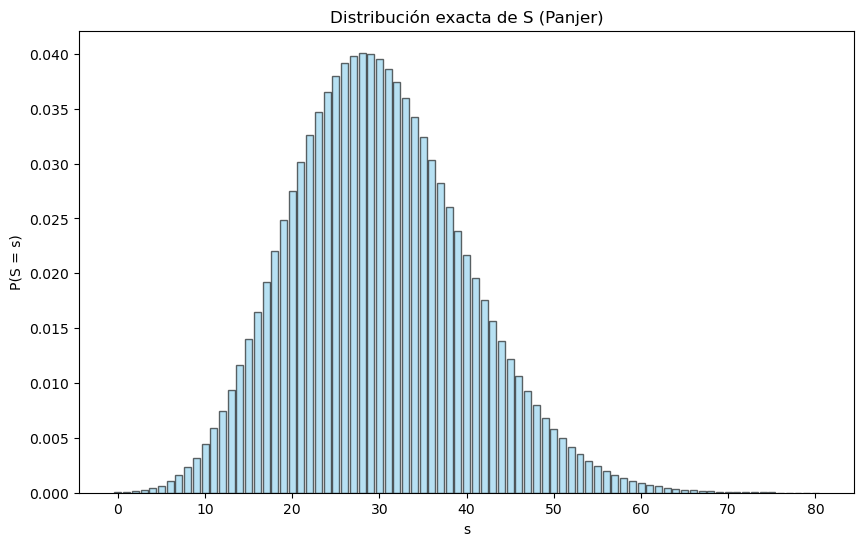

In [24]:
# Panjer con Poisson
max_S = 80
f = np.zeros(max_S + 1)
f[x_vals] = f_x

g = np.zeros(max_S + 1)
g[0] = np.exp(-lam * (1 - f[0]))

for s in range(1, max_S + 1):
    g[s] = sum((lam * k / s) * f[k] * g[s - k] for k in range(1, s + 1))

x = np.arange(max_S + 1)

plt.figure(figsize=(10, 6))
plt.bar(x, g, color='skyblue', edgecolor='black', alpha=0.6)
plt.title("Distribución exacta de S (Panjer)")
plt.xlabel("s")
plt.ylabel("P(S = s)")
plt.grid(False)
plt.show()

In [25]:
# Aproximación Normal
norm_approx = norm.pdf(x, E_S, sigma_S)

# Aproximación Gamma trasladada
gamma_param = 4 / a3**2
alpha_param = sigma_S * a3 / 2
k = E_S - 2 * sigma_S / a3

x_plot = np.linspace(max(0, k), E_S + 4 * sigma_S, 1000)
gamma_pdf = np.where(x_plot >= k,
                     gamma.pdf(x_plot - k, gamma_param, scale=alpha_param),
                     0)

# Aproximación de Edgeworth
def edgeworth_density(s):
    z = (s - E_S) / sigma_S
    phi_z = norm.pdf(z)
    phi3_z = (3*z - z**3) * phi_z
    phi4_z = (3 - 6*z**2 + z**4) * phi_z
    phi6_z = (-15 + 45*z**2 - 15*z**4 + z**6) * phi_z
    f_z = phi_z - (a3/6) * phi3_z + (a4/24) * phi4_z + (a3**2/72) * phi6_z
    return f_z / sigma_S

s_values = np.linspace(0, max_S, 1000)
edgeworth_dens = edgeworth_density(s_values)

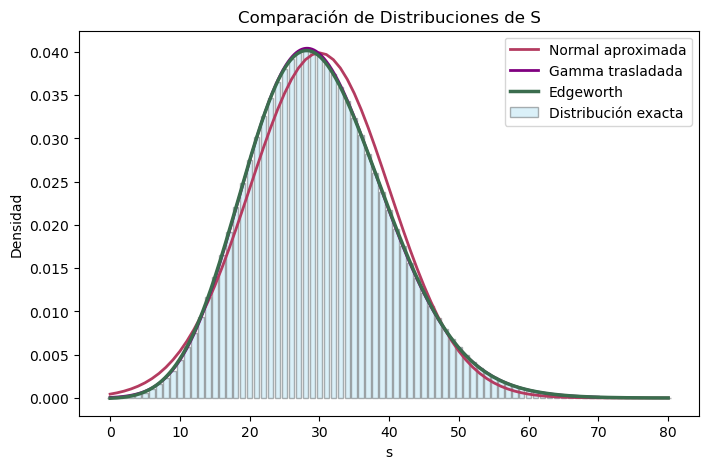

In [ ]:
## Gráfica de comparación

plt.figure(figsize=(8, 5))
plt.bar(x, g, color='skyblue', edgecolor='black', alpha=0.3, label='Distribución exacta')
plt.plot(x, norm_approx, color="#B43B60", linewidth=2, label='Normal aproximada')
plt.plot(x_plot, gamma_pdf, color='#800080', linewidth=2, label='Gamma trasladada')
plt.plot(s_values, edgeworth_dens, color="#3B6D4E", linewidth=2.5, label='Edgeworth')
plt.title("Comparación de Distribuciones de S")
plt.xlabel("s")
plt.ylabel("Densidad")
plt.legend()
plt.grid(False)
plt.show()

#### **Suma de dos Poisson compuestas independientes**

S = S1 + S2, donde S1 es Poisson compuesta con λ1 = 10 y montos 1, 2, 3, 10 con probabilidad 1/4 cada uno, y S2 es Poisson compuesta con λ2 = 20 y f_X(x) = x/10 para x = 1, 2, 3, 4. Se calcula la distribución exacta de cada una con Panjer, se obtiene la de S por convolución y se compara con la aproximación Normal.

In [27]:
def panjer_poisson(lambda_, f, s_max):
    g = np.zeros(s_max + 1)
    g[0] = np.exp(-lambda_)
    for s in range(1, s_max + 1):
        g[s] = (lambda_ / s) * sum(j * pj * g[s - j] for j, pj in f.items() if j <= s)
    return g

lambda1 = 10
lambda2 = 20

f1 = {1: 1/4, 2: 1/4, 3: 1/4, 10: 1/4}
f2 = {1: 1/10, 2: 2/10, 3: 3/10, 4: 4/10}

# Aplicamos Panjer
s_max = 250
g1 = panjer_poisson(lambda1, f1, s_max)
g2 = panjer_poisson(lambda2, f2, s_max)

# S = S1 + S2 (convolución)
gS = np.convolve(g1, g2)[:s_max + 1]

# Momentos de S
mu_S = lambda1 * sum(j * p for j, p in f1.items()) + lambda2 * sum(j * p for j, p in f2.items())
var_S = lambda1 * sum(j**2 * p for j, p in f1.items()) + lambda2 * sum(j**2 * p for j, p in f2.items())
sigma_S = np.sqrt(var_S)

print("E[S] =", mu_S, " Var[S] =", var_S)

E[S] = 100.0  Var[S] = 485.0


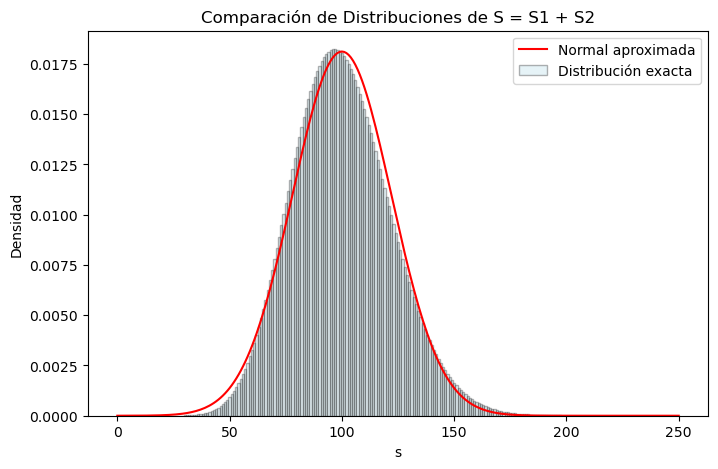

In [28]:
s_vals = np.arange(len(gS))
norm_approx = norm.pdf(s_vals, mu_S, sigma_S)

plt.figure(figsize=(8, 5))
plt.bar(s_vals, gS, color='lightblue', alpha=0.3, edgecolor='black', width=1, label='Distribución exacta')
plt.plot(s_vals, norm_approx, 'r-', label='Normal aproximada')
plt.title("Comparación de Distribuciones de S = S1 + S2")
plt.xlabel("s")
plt.ylabel("Densidad")
plt.legend()
plt.grid(False)
plt.show()